# Anti-Money Laundering — Decision Tree

### Contextualización Teórica y Matemática
Los **Árboles de Decisión (Decision Trees)** son algoritmos no paramétricos impulsados por la subdivisión del espacio de características a través de divisiones ortogonales (*recursive binary splitting*). Modelan las probabilidades predictivas particionando recursivamente los datos de entrada según sus características observadas $(X)$ para discernir entre transacciones lícitas y operaciones fraudulentas ("Lavado").

Matemáticamente, la construcción top-down del árbol se fundamenta en iterar sobre todas las particiones probables y optimizar la **Criterio de Impureza (Impurity)** o la **Ganancia de Información**.
Las métricas clásicas empleadas para medir la "pureza" de clasificación de las porciones de operaciones financieras antes y después del corte son:

- **Impureza de Gini (*Gini Index*):** Cuantifica la probabilidad heurística de clasificar incorrectamente una transacción escogida al azar de un mini-lote, si se etiquetara de acuerdo con la distribución de clases original.
  $$ Gini(p) = 1 - \sum_{i=1}^{C} p_i^2 $$
  Donde $p_i$ es la fracción de transacciones pertenecientes a la clase $i$ en ese nodo particular. El árbol buscará siempre las variables que minimicen esta impureza geométrica.

- **Entropía (*Information Gain*):** Concepto prestado de la teoría de la información abstracta. Mide el nivel del "desorden" estructural residual de las clasificaciones de delitos AML tras analizar ciertas características y dividirlas:
  $$ H(p) = - \sum_{i=1}^{C} p_i \log_2(p_i) $$


## Sección 1 · Imports y Configuración


In [3]:
!pip install deap optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 45.5 MB/s eta 0:00:00


In [4]:
import warnings, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import randint

from sklearn.base            import BaseEstimator, ClassifierMixin
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc, f1_score, roc_auc_score
)

from imblearn.pipeline      import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.base          import BaseSampler

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from deap import base, creator, tools, algorithms

warnings.filterwarnings("ignore")
sns.set_theme(style='ticks', context='paper', font_scale=1.2, palette='Set1')

# ── Constantes globales ────────────────────────────────────────────────────────
RANDOM_STATE    = 42
N_SPLITS        = 3      # TimeSeriesSplit folds (cronológico, nunca KFold aleatorio)
N_ITER_RANDOM   = 20     # Random Search: iteraciones totales
N_TRIALS_OPTUNA = 30     # Optuna: trials totales
POP_SIZE        = 10     # DEAP: tamaño de la población
N_GEN           = 5      # DEAP: número de generaciones
BASE_PATH       = '/content/drive/MyDrive/Datasets/Final Project/Processed/'

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Sección 2 · Clases Auxiliares


In [5]:
# ── Verificar GPU ─────────────────────────────────────────────────────────────
!nvidia-smi

Tue May 19 01:33:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   33C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# ── Instalar cuML ─────────────────────────────────────────────────────────────
!pip uninstall -y cupy cupy-cuda11x 2>/dev/null
!pip install --extra-index-url=https://pypi.nvidia.com \
             --extra-index-url=https://pypi.ngc.nvidia.com \
             cudf-cu12 cuml-cu12 -q

In [7]:
# cuML no tiene DecisionTreeClassifier como clase independiente.
# Se reproduce con RandomForestClassifier(n_estimators=1, bootstrap=False),
# que es matemáticamente equivalente a un árbol de decisión individual.
from cuml.ensemble import RandomForestClassifier as cuRFC


class IdentitySampler(BaseSampler):
    """Bypass: no aplica ningún oversampling, pasa los datos tal cual."""
    _sampling_type         = "bypass"
    _parameter_constraints = {}

    def _fit_resample(self, X, y):
        return X, y

    def __repr__(self):
        return "IdentitySampler()"


class DynamicBalanceDT(BaseEstimator, ClassifierMixin):
    """
    Árbol de Decisión sobre GPU via cuML RandomForestClassifier(n_estimators=1,
    bootstrap=False), que es equivalente a un DecisionTreeClassifier individual.

    Parámetros expuestos al espacio de búsqueda:
      - max_depth          : profundidad máxima (None → sin límite, mapeado a -1 en cuML)
      - min_samples_split  : mínimo de muestras para dividir un nodo interno
      - min_samples_leaf   : mínimo de muestras en una hoja
      - criterion          : 'gini' o 'entropy'
      - use_balanced_weight: si True, balancea clases manualmente via sample_weight

    Nota: cuML RF no acepta class_weight; el balanceo se implementa calculando
    sample_weight inversamente proporcional a la frecuencia de clase.
    """
    def __init__(self, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, criterion='gini',
                 use_balanced_weight=False, random_state=RANDOM_STATE):
        self.max_depth            = max_depth
        self.min_samples_split    = min_samples_split
        self.min_samples_leaf     = min_samples_leaf
        self.criterion            = criterion
        self.use_balanced_weight  = use_balanced_weight
        self.random_state         = random_state
        self.model_               = None

    def _compute_sample_weight(self, y):
        """Calcula sample_weight balanceado (inverso de frecuencia de clase)."""
        classes, counts = np.unique(y, return_counts=True)
        freq = dict(zip(classes, counts))
        n_samples = len(y)
        n_classes  = len(classes)
        weights = np.array([
            n_samples / (n_classes * freq[yi]) for yi in y
        ], dtype=np.float32)
        return weights

    def fit(self, X, y, **kwargs):
        # cuML RF usa max_depth=-1 para indicar sin límite
        md = self.max_depth if self.max_depth is not None else -1
        self.model_ = cuRFC(
            n_estimators      = 1,          # 1 árbol = DecisionTree equivalente
            bootstrap         = False,      # sin bootstrap → usa todos los datos
            max_depth         = md,
            min_samples_split = self.min_samples_split,
            min_samples_leaf  = self.min_samples_leaf,
            split_criterion   = self.criterion,  # cuML usa split_criterion, no criterion
            random_state      = self.random_state,
            n_streams         = 1,
        )
        X_fit = np.asarray(X, dtype=np.float32)
        y_fit = np.asarray(y, dtype=np.int32)
        if self.use_balanced_weight:
            sw = self._compute_sample_weight(y_fit)
            self.model_.fit(X_fit, y_fit, sample_weight=sw)
        else:
            self.model_.fit(X_fit, y_fit)
        self.classes_ = np.unique(y_fit)
        return self

    def predict(self, X):
        return self.model_.predict(np.asarray(X, dtype=np.float32))

    def predict_proba(self, X):
        return self.model_.predict_proba(np.asarray(X, dtype=np.float32))

    @property
    def feature_importances_(self):
        """Importancia de features del árbol entrenado."""
        return self.model_.feature_importances_ if self.model_ is not None else None

## Sección 3 · Carga de Datos


In [8]:
from google.colab import drive
drive.mount('/content/drive')

X_train = pd.read_parquet(f'{BASE_PATH}X_train.parquet')
X_test  = pd.read_parquet(f'{BASE_PATH}X_test.parquet')
y_train = pd.read_parquet(f'{BASE_PATH}y_train.parquet')['Is Laundering']
y_test  = pd.read_parquet(f'{BASE_PATH}y_test.parquet')['Is Laundering']

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}  | y_test  : {y_test.shape}")
print(f"Prevalencia Lavado — Train: {y_train.mean():.4%} | Test: {y_test.mean():.4%}")

Mounted at /content/drive
X_train : (4062668, 45) | y_train : (4062668,)
X_test  : (1015668, 45)  | y_test  : (1015668,)
Prevalencia Lavado — Train: 0.0832% | Test: 0.1770%


## Sección 4 · Configuraciones Compartidas


In [9]:
TSCV = TimeSeriesSplit(n_splits=N_SPLITS)

BALANCE_CONFIGS = [
    {'id': 0, 'name': 'Sin balanceo',             'use_bw': False},
    {'id': 1, 'name': 'SMOTE',                     'use_bw': False},
    {'id': 2, 'name': 'ADASYN',                    'use_bw': False},
]

def get_fresh_sampler(bal_id):
    """Retorna una instancia nueva del sampler para evitar estado residual."""
    if bal_id == 1: return SMOTE(random_state=RANDOM_STATE)
    if bal_id == 2: return ADASYN(random_state=RANDOM_STATE)
    return IdentitySampler()

# ── Espacio Grid Search ────────────────────────────────────────────────────────
# 5×3×3×2 = 90 combinaciones × 3 estrategias = 270 configs
# 270 × 3 folds = 810 entrenamientos DT
PARAM_GRID = {
    'clf__max_depth'        : [3, 5, 10, 15, None],
    'clf__min_samples_split': [2, 10, 20],
    'clf__min_samples_leaf' : [1, 5, 10],
    'clf__criterion'        : ['gini', 'entropy'],
}

# ── Espacio Random Search: distribuciones discretas ───────────────────────────
PARAM_DIST = {
    'clf__max_depth'        : [None] + list(range(2, 31)),   # None incluido
    'clf__min_samples_split': randint(2, 51),
    'clf__min_samples_leaf' : randint(1, 31),
    'clf__criterion'        : ['gini', 'entropy'],
}

RESULTS = {}  # Diccionario global de resultados

# ── Helpers de convergencia ────────────────────────────────────────────────────
def converged_optuna(study, patience=10):
    """True si el mejor valor acumulado no mejoró en los últimos `patience` trials."""
    vals = [t.value for t in study.trials if t.value is not None]
    if len(vals) < patience:
        return False
    best = [max(vals[:i + 1]) for i in range(len(vals))]
    return len(set(best[-patience:])) == 1


def converged_deap(logbook, patience=2):
    """True si el F1 máximo no mejoró en las últimas `patience` generaciones."""
    maxes = logbook.select('max')
    if len(maxes) <= patience:
        return False
    return maxes[-1] == maxes[-(patience + 1)]


# ── Helpers DEAP: cromosoma de 5 genes ───────────────────────────────────────
# Gen 0: balance_strategy  (int   0–2)
# Gen 1: max_depth         (int   0–30)   0 = sin límite (cuML)
# Gen 2: min_samples_split (int   2–50)
# Gen 3: min_samples_leaf  (int   1–30)
# Gen 4: criterion         (int   0=gini, 1=entropy)

def decode_individual(ind):
    """Traduce los 5 genes del individuo a parámetros interpretables."""
    bal_id            = int(np.clip(ind[0], 0, 2))
    max_depth_raw     = int(ind[1])
    max_depth         = None if max_depth_raw <= 0 else max_depth_raw
    min_samples_split = max(2, int(ind[2]))
    min_samples_leaf  = max(1, int(ind[3]))
    criterion         = 'gini' if int(ind[4]) == 0 else 'entropy'
    return bal_id, max_depth, min_samples_split, min_samples_leaf, criterion


def mutate_individual(individual, indpb):
    """Mutación personalizada con restricciones de rango por gen."""
    if random.random() < indpb: individual[0] = random.randint(0, 2)
    if random.random() < indpb: individual[1] = random.randint(0, 30)   # 0 = sin límite
    if random.random() < indpb: individual[2] = random.randint(2, 50)
    if random.random() < indpb: individual[3] = random.randint(1, 30)
    if random.random() < indpb: individual[4] = random.randint(0, 1)
    return individual,


def _init_deap_toolbox(evaluate_fn, X_train, y_train):
    """Registra los operadores DEAP y retorna el toolbox configurado."""
    if hasattr(creator, 'FitnessMax'): del creator.FitnessMax
    if hasattr(creator, 'Individual'): del creator.Individual
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
    creator.create('Individual', list, fitness=creator.FitnessMax)

    cv      = TimeSeriesSplit(n_splits=N_SPLITS)
    toolbox = base.Toolbox()
    toolbox.register('attr_bal',       random.randint,  0,  2)
    toolbox.register('attr_depth',     random.randint,  0, 30)
    toolbox.register('attr_split',     random.randint,  2, 50)
    toolbox.register('attr_leaf',      random.randint,  1, 30)
    toolbox.register('attr_criterion', random.randint,  0,  1)
    toolbox.register(
        'individual', tools.initCycle, creator.Individual,
        (toolbox.attr_bal, toolbox.attr_depth, toolbox.attr_split,
         toolbox.attr_leaf, toolbox.attr_criterion), n=1
    )
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    toolbox.register('evaluate', evaluate_fn, X=X_train, y=y_train, cv=cv)
    toolbox.register('mate',   tools.cxTwoPoint)
    toolbox.register('mutate', mutate_individual, indpb=0.25)
    toolbox.register('select', tools.selTournament, tournsize=3)
    return toolbox


def _run_deap(toolbox, pop_size, n_gen):
    """Ejecuta eaSimple y retorna (best_ind, logbook, elapsed_min)."""
    pop   = toolbox.population(n=pop_size)
    hof   = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register('avg', np.mean)
    stats.register('max', np.max)

    t0 = time.time()
    pop, logbook = algorithms.eaSimple(
        pop, toolbox, cxpb=0.5, mutpb=0.2,
        ngen=n_gen, stats=stats, halloffame=hof, verbose=True
    )
    elapsed = (time.time() - t0) / 60
    return hof[0], logbook, elapsed


# ── Construcción y predicción del modelo final ────────────────────────────────
def build_final_model(spec, X_train, y_train):
    """
    Reconstruye y entrena el pipeline final en todo X_train.
    spec = {'bal_id': int, 'max_depth': int|None, 'min_samples_split': int,
            'min_samples_leaf': int, 'criterion': str}
    """
    sampler = get_fresh_sampler(spec['bal_id'])
    use_bw  = BALANCE_CONFIGS[spec['bal_id']]['use_bw']
    pipe = Pipeline([
        ('scaler',  StandardScaler()),
        ('sampler', sampler),
        ('clf',     DynamicBalanceDT(
                        max_depth          = spec['max_depth'],
                        min_samples_split  = spec['min_samples_split'],
                        min_samples_leaf   = spec['min_samples_leaf'],
                        criterion          = spec['criterion'],
                        use_balanced_weight= use_bw,
                        random_state       = RANDOM_STATE)),
    ])
    pipe.fit(X_train, y_train)
    return pipe


def predict_final(model, X_test):
    """Genera (y_pred, y_proba) del pipeline final."""
    return model.predict(X_test), model.predict_proba(X_test)[:, 1]


def timeit_inference(pipe, X, reps=50):
    """Tiempo medio de predicción sobre X (en segundos)."""
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        pipe.predict(X)
        times.append(time.perf_counter() - t0)
    return np.mean(times)


## Sección 5 · Decision Tree — Grid Search


In [11]:
def run_grid_search_dt(X_train, y_train):
    n_combos = 1
    for v in PARAM_GRID.values():
        n_combos *= len(v)

    print(f"{'═'*62}")
    print(f" Grid Search — Decision Tree")
    print(f"{'═'*62}")
    print(f" Combinaciones por estrategia : {n_combos}")
    print(f" Configs totales evaluadas    : {n_combos * len(BALANCE_CONFIGS)}")
    print(f" Fits totales (× {N_SPLITS} folds)     : {n_combos * len(BALANCE_CONFIGS) * N_SPLITS}\n")

    best_f1, best_spec, best_bal_name = -1, None, None
    t0 = time.time()

    for bal_cfg in BALANCE_CONFIGS:
        sampler = get_fresh_sampler(bal_cfg['id'])
        pipe    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceDT(use_balanced_weight=bal_cfg['use_bw'])),
        ])
        search = GridSearchCV(pipe, PARAM_GRID, cv=TSCV,
                              scoring='f1', n_jobs=6, refit=False)
        search.fit(X_train, y_train)

        score = search.best_score_
        print(f"  [{bal_cfg['name']:35s}]  F1 CV = {score:.4f}")

        if score > best_f1:
            best_f1       = score
            best_bal_name = bal_cfg['name']
            p             = search.best_params_
            best_spec     = {
                'bal_id'           : bal_cfg['id'],
                'max_depth'        : p['clf__max_depth'],
                'min_samples_split': p['clf__min_samples_split'],
                'min_samples_leaf' : p['clf__min_samples_leaf'],
                'criterion'        : p['clf__criterion'],
            }

    elapsed = (time.time() - t0) / 60
    n_evals = n_combos * len(BALANCE_CONFIGS)

    print(f"\n  ✓ Mejor F1 (CV) : {best_f1:.4f}  |  Balanceo : {best_bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  Evaluaciones : {n_evals}")

    RESULTS['dt_grid'] = {
        'label'       : 'Decision Tree',
        'method'      : 'Grid Search',
        'best_f1'     : round(best_f1, 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_evals,
        'converged'   : 'N/A',
        'best_balance': best_bal_name,
        'spec'        : best_spec,
    }
    return RESULTS['dt_grid']


result_grid = run_grid_search_dt(X_train, y_train)

══════════════════════════════════════════════════════════════
 Grid Search — Decision Tree
══════════════════════════════════════════════════════════════
 Combinaciones por estrategia : 90
 Configs totales evaluadas    : 270
 Fits totales (× 3 folds)     : 810

  [Sin balanceo                       ]  F1 CV = 0.0555
  [SMOTE                              ]  F1 CV = 0.0192
  [ADASYN                             ]  F1 CV = 0.0228

  ✓ Mejor F1 (CV) : 0.0555  |  Balanceo : Sin balanceo
  ✓ Tiempo total  : 30.9 min  |  Evaluaciones : 270


## Sección 6 · Decision Tree — Random Search


In [13]:
def run_random_search_dt(X_train, y_train, n_iter=N_ITER_RANDOM):
    print(f"{'═'*62}")
    print(f" Random Search — Decision Tree")
    print(f"{'═'*62}")
    print(f" Iteraciones por estrategia : {n_iter}")
    print(f" Configs totales evaluadas  : {n_iter * len(BALANCE_CONFIGS)}\n")

    best_f1, best_spec, best_bal_name = -1, None, None
    t0 = time.time()

    for bal_cfg in BALANCE_CONFIGS:
        sampler = get_fresh_sampler(bal_cfg['id'])
        pipe    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceDT(use_balanced_weight=bal_cfg['use_bw'])),
        ])
        search = RandomizedSearchCV(pipe, PARAM_DIST, n_iter=n_iter, cv=TSCV,
                                    scoring='f1', n_jobs=6, refit=False,
                                    random_state=RANDOM_STATE)
        search.fit(X_train, y_train)

        score = search.best_score_
        print(f"  [{bal_cfg['name']:35s}]  F1 CV = {score:.4f}")

        if score > best_f1:
            best_f1       = score
            best_bal_name = bal_cfg['name']
            p             = search.best_params_
            best_spec     = {
                'bal_id'           : bal_cfg['id'],
                'max_depth'        : p['clf__max_depth'],
                'min_samples_split': p['clf__min_samples_split'],
                'min_samples_leaf' : p['clf__min_samples_leaf'],
                'criterion'        : p['clf__criterion'],
            }

    elapsed = (time.time() - t0) / 60
    n_evals = n_iter * len(BALANCE_CONFIGS)

    print(f"\n  ✓ Mejor F1 (CV) : {best_f1:.4f}  |  Balanceo : {best_bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  Evaluaciones : {n_evals}")

    RESULTS['dt_random'] = {
        'label'       : 'Decision Tree',
        'method'      : 'Random Search',
        'best_f1'     : round(best_f1, 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_evals,
        'converged'   : 'N/A',
        'best_balance': best_bal_name,
        'spec'        : best_spec,
    }
    return RESULTS['dt_random']


result_random = run_random_search_dt(X_train, y_train)

══════════════════════════════════════════════════════════════
 Random Search — Decision Tree
══════════════════════════════════════════════════════════════
 Iteraciones por estrategia : 20
 Configs totales evaluadas  : 60

  [Sin balanceo                       ]  F1 CV = 0.0590
  [SMOTE                              ]  F1 CV = 0.0260
  [ADASYN                             ]  F1 CV = 0.0364

  ✓ Mejor F1 (CV) : 0.0590  |  Balanceo : Sin balanceo
  ✓ Tiempo total  : 7.2 min  |  Evaluaciones : 60


## Sección 7 · Decision Tree — Bayesiano (Optuna / TPE)


In [15]:
def run_optuna_dt(X_train, y_train, n_trials=N_TRIALS_OPTUNA):
    print(f"{'═'*62}")
    print(f" Bayesiano (Optuna/TPE) — Decision Tree")
    print(f"{'═'*62}")
    print(f" Trials : {n_trials}  |  CV : {N_SPLITS}-fold TimeSeriesSplit\n")

    def objective(trial):
        bal_id            = trial.suggest_int('balance_strategy', 0, 2)
        max_depth_raw     = trial.suggest_int('max_depth', 0, 30)   # 0 = sin límite
        max_depth         = None if max_depth_raw == 0 else max_depth_raw
        min_samples_split = trial.suggest_int('min_samples_split', 2, 50)
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 30)
        criterion         = trial.suggest_categorical('criterion', ['gini', 'entropy'])

        bal_cfg = BALANCE_CONFIGS[bal_id]
        sampler = get_fresh_sampler(bal_id)
        pipe    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceDT(
                            max_depth          = max_depth,
                            min_samples_split  = min_samples_split,
                            min_samples_leaf   = min_samples_leaf,
                            criterion          = criterion,
                            use_balanced_weight= bal_cfg['use_bw'],
                            random_state       = RANDOM_STATE)),
        ])
        scores = cross_val_score(pipe, X_train, y_train, cv=TSCV,
                                 scoring='f1', n_jobs=6, error_score=0.0)
        return scores.mean()

    t0    = time.time()
    study = optuna.create_study(
        direction = 'maximize',
        sampler   = TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    elapsed = (time.time() - t0) / 60

    best    = study.best_trial
    bal_cfg = BALANCE_CONFIGS[best.params['balance_strategy']]
    conv    = converged_optuna(study)

    max_depth_raw = best.params['max_depth']
    max_depth     = None if max_depth_raw == 0 else max_depth_raw

    print(f"\n  ✓ Mejor F1 (CV) : {best.value:.4f}  |  Balanceo : {bal_cfg['name']}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS['dt_optuna'] = {
        'label'       : 'Decision Tree',
        'method'      : 'Bayesiano',
        'best_f1'     : round(best.value, 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_trials,
        'converged'   : 'Sí' if conv else 'No',
        'best_balance': bal_cfg['name'],
        'spec'        : {
            'bal_id'           : best.params['balance_strategy'],
            'max_depth'        : max_depth,
            'min_samples_split': best.params['min_samples_split'],
            'min_samples_leaf' : best.params['min_samples_leaf'],
            'criterion'        : best.params['criterion'],
        },
        'study': study,
    }
    return RESULTS['dt_optuna']


result_optuna = run_optuna_dt(X_train, y_train)


══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — Decision Tree
══════════════════════════════════════════════════════════════
 Trials : 30  |  CV : 3-fold TimeSeriesSplit



  0%|          | 0/30 [00:00<?, ?it/s]


  ✓ Mejor F1 (CV) : 0.0365  |  Balanceo : ADASYN
  ✓ Tiempo total  : 12.8 min  |  ¿Convergió? : No


## Sección 8 · Decision Tree — DEAP (Algoritmo Genético)


In [17]:
def evaluate_individual_dt(individual, X, y, cv):
    bal_id, max_depth, min_samples_split, min_samples_leaf, criterion = \
        decode_individual(individual)

    # cuML requiere max_depth > 0. Reemplazamos None con 30 (límite superior empírico)
    eff_max_depth = 30 if max_depth is None else max_depth

    bal_cfg = BALANCE_CONFIGS[bal_id]
    sampler = get_fresh_sampler(bal_id)
    pipe    = Pipeline([
        ('scaler',  StandardScaler()),
        ('sampler', sampler),
        ('clf',     DynamicBalanceDT(
                        max_depth          = eff_max_depth,
                        min_samples_split  = min_samples_split,
                        min_samples_leaf   = min_samples_leaf,
                        criterion          = criterion,
                        use_balanced_weight= bal_cfg['use_bw'],
                        random_state       = RANDOM_STATE)),
    ])
    scores = cross_val_score(pipe, X, y, cv=cv,
                             scoring='f1', n_jobs=4, error_score=0.0)
    return (scores.mean(),)


def run_deap_dt(X_train, y_train, pop_size=POP_SIZE, n_gen=N_GEN):
    print(f"{'═'*62}")
    print(f" DEAP (Genético) — Decision Tree")
    print(f"{'═'*62}")
    print(f" Población : {pop_size}  |  Generaciones : {n_gen}  |  CV : {N_SPLITS}-fold\n")

    toolbox = _init_deap_toolbox(evaluate_individual_dt, X_train, y_train)
    best_ind, logbook, elapsed = _run_deap(toolbox, pop_size, n_gen)

    bal_id, max_depth, min_samples_split, min_samples_leaf, criterion = \
        decode_individual(best_ind)
    bal_name = BALANCE_CONFIGS[bal_id]['name']
    conv     = converged_deap(logbook)
    n_evals  = pop_size * n_gen

    eff_max_depth = 30 if max_depth is None else max_depth

    print(f"\n  ✓ Mejor F1 (CV) : {best_ind.fitness.values[0]:.4f}  |  Balanceo : {bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS['dt_deap'] = {
        'label'       : 'Decision Tree',
        'method'      : 'DEAP (Genético)',
        'best_f1'     : round(best_ind.fitness.values[0], 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_evals,
        'converged'   : 'Sí' if conv else 'No',
        'best_balance': bal_name,
        'spec'        : {
            'bal_id'           : bal_id,
            'max_depth'        : eff_max_depth,
            'min_samples_split': min_samples_split,
            'min_samples_leaf' : min_samples_leaf,
            'criterion'        : criterion,
        },
        'logbook': logbook,
    }
    return RESULTS['dt_deap']


result_deap = run_deap_dt(X_train, y_train)


══════════════════════════════════════════════════════════════
 DEAP (Genético) — Decision Tree
══════════════════════════════════════════════════════════════
 Población : 10  |  Generaciones : 5  |  CV : 3-fold

gen	nevals	avg     	max      
0  	10    	0.013273	0.0348619
1  	8     	0.018287	0.0348619
2  	8     	0.02412 	0.0339324
3  	5     	0.0268234	0.0339324
4  	7     	0.0299141	0.0339324
5  	7     	0.027243 	0.0339324

  ✓ Mejor F1 (CV) : 0.0349  |  Balanceo : ADASYN
  ✓ Tiempo total  : 10.3 min  |  ¿Convergió? : Sí


## Sección 9 · Optimización Computacional — Curva de Profundidad y Análisis de Poda

Generando curva de profundidad (F1-CV vs max_depth)...
  ✓ Profundidad óptima Gini    (CV) : None  →  F1 = 0.0679
  ✓ Profundidad óptima Entropy (CV) : None  →  F1 = 0.0391


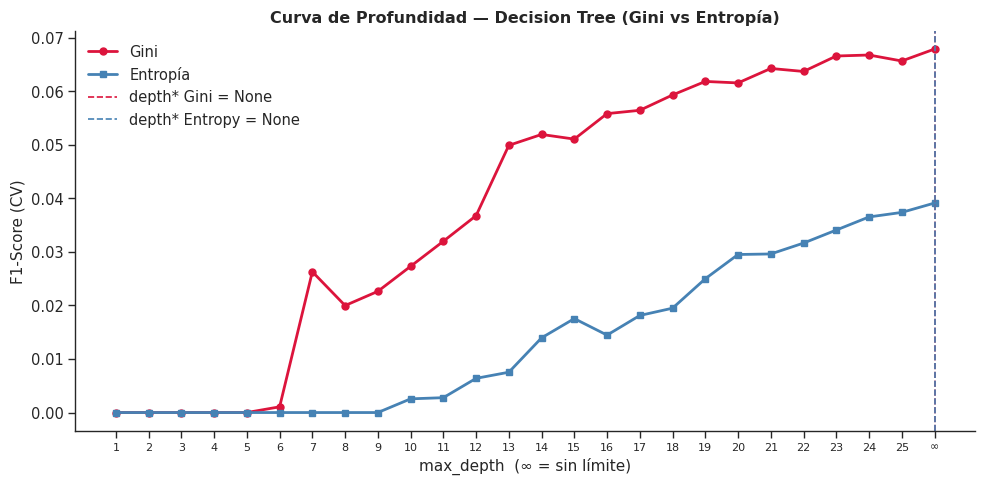

In [19]:
# ── 9.1 Curva F1-CV vs max_depth ──────────────────────────────────────────────
print("Generando curva de profundidad (F1-CV vs max_depth)...")

depth_values = list(range(1, 26)) + [None]  # 1–25 + sin límite
depth_labels = list(range(1, 26)) + [26]    # 26 representa None en el eje x

# Usar la mejor estrategia de balanceo encontrada hasta ahora
best_key_r9 = max(RESULTS, key=lambda k: RESULTS[k]['best_f1'])
best_bal_id = RESULTS[best_key_r9]['spec']['bal_id']
use_bw_r9   = BALANCE_CONFIGS[best_bal_id]['use_bw']
best_crit   = RESULTS[best_key_r9]['spec']['criterion']

f1_gini_cv    = []
f1_entropy_cv = []

for d in depth_values:
    for crit, f1_list in [('gini', f1_gini_cv), ('entropy', f1_entropy_cv)]:
        eff_depth = 30 if d is None else d
        sampler_i = get_fresh_sampler(best_bal_id)
        pipe_i    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler_i),
            ('clf',     DynamicBalanceDT(
                            max_depth          = eff_depth,
                            min_samples_split  = 2,
                            min_samples_leaf   = 1,
                            criterion          = crit,
                            use_balanced_weight= use_bw_r9,
                            random_state       = RANDOM_STATE)),
        ])
        score = cross_val_score(pipe_i, X_train, y_train, cv=TSCV,
                                scoring='f1', n_jobs=4, error_score=0.0).mean()
        f1_list.append(score)

best_depth_gini    = depth_values[np.argmax(f1_gini_cv)]
best_depth_entropy = depth_values[np.argmax(f1_entropy_cv)]
print(f"  ✓ Profundidad óptima Gini    (CV) : {best_depth_gini}  →  F1 = {max(f1_gini_cv):.4f}")
print(f"  ✓ Profundidad óptima Entropy (CV) : {best_depth_entropy}  →  F1 = {max(f1_entropy_cv):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depth_labels, f1_gini_cv,    'o-', color='crimson',   lw=2, ms=5, label='Gini')
ax.plot(depth_labels, f1_entropy_cv, 's-', color='steelblue', lw=2, ms=5, label='Entropía')

best_lbl_gini    = depth_labels[depth_values.index(best_depth_gini)]
best_lbl_entropy = depth_labels[depth_values.index(best_depth_entropy)]
ax.axvline(best_lbl_gini,    color='crimson',   linestyle='--', lw=1.2,
           label=f'depth* Gini = {best_depth_gini}')
ax.axvline(best_lbl_entropy, color='steelblue', linestyle='--', lw=1.2,
           label=f'depth* Entropy = {best_depth_entropy}')

ax.set_xticks(list(range(1, 27)))
ax.set_xticklabels([str(d) for d in range(1, 26)] + ['∞'], fontsize=8)
ax.set_xlabel('max_depth  (∞ = sin límite)', fontsize=11)
ax.set_ylabel('F1-Score (CV)', fontsize=11)
ax.set_title('Curva de Profundidad — Decision Tree (Gini vs Entropía)', fontweight='bold')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}depth_curve_dt.png', dpi=150, bbox_inches='tight')
plt.show()


La curva de optimización hiperparamétrica para el Árbol de Decisión revela una clara e inusual tendencia ascendente en el rendimiento (F1-Score) conforme se incrementa la profundidad, alcanzando sus puntos máximos en ambos criterios cuando no se establece ningún límite estructural (`max_depth = None` o $\infty$), con un **F1-Score de 0.0679 para Gini** y **0.0391 para Entropía**. A profundidades bajas ($\le 5$), el modelo sufre de un subajuste (*underfitting*) absoluto con rendimiento nulo debido a la incapacidad de segmentar el espacio ante un desbalanceo extremo, pero a partir de `max_depth = 6` para Gini y `max_depth = 10` para Entropía, los algoritmos logran aislar de forma efectiva los patrones minoritarios de lavado, demostrando que el criterio de **Gini exhibe una superioridad consistente y una velocidad de aprendizaje más acelerada** que la Entropía a lo largo de todo el espectro de profundidad.

In [21]:
# ── 9.2 Árbol podado vs árbol sin podar ───────────────────────────────────────
best_crit_r9 = ('gini' if max(f1_gini_cv) >= max(f1_entropy_cv) else 'entropy')
best_d_r9    = best_depth_gini if best_crit_r9 == 'gini' else best_depth_entropy

eff_best_d_r9 = 30 if best_d_r9 is None else best_d_r9

spec_pruned   = {
    'bal_id': best_bal_id, 'max_depth': eff_best_d_r9,
    'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': best_crit_r9,
}
spec_unpruned = {
    'bal_id': best_bal_id, 'max_depth': 30,
    'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': best_crit_r9,
}

print("\nEntrenando árbol podado y sin podar...")
pipe_pruned   = build_final_model(spec_pruned,   X_train, y_train)
pipe_unpruned = build_final_model(spec_unpruned, X_train, y_train)

t_pruned   = timeit_inference(pipe_pruned,   X_test, reps=50)
t_unpruned = timeit_inference(pipe_unpruned, X_test, reps=50)

f1_pruned   = f1_score(y_test, pipe_pruned.predict(X_test))
f1_unpruned = f1_score(y_test, pipe_unpruned.predict(X_test))

print(f"\n{'═'*62}")
print(f" Comparativa: Árbol Podado vs Sin Podar  (criterio = {best_crit_r9})")
print(f"{'═'*62}")
print(f"{'Métrica':<32} {'Podado':>14} {'Sin Podar':>14}")
print(f"{'─'*60}")
print(f"{'max_depth':<32} {str(best_d_r9):>14} {'None (∞)':>14}")
print(f"{'Tiempo inferencia (ms)':<32} {t_pruned*1000:>14.3f} {t_unpruned*1000:>14.3f}")
print(f"{'F1-Score (test)':<32} {f1_pruned:>14.4f} {f1_unpruned:>14.4f}")
print(f"{'═'*62}")



Entrenando árbol podado y sin podar...

══════════════════════════════════════════════════════════════
 Comparativa: Árbol Podado vs Sin Podar  (criterio = gini)
══════════════════════════════════════════════════════════════
Métrica                                  Podado      Sin Podar
────────────────────────────────────────────────────────────
max_depth                                  None       None (∞)
Tiempo inferencia (ms)                  442.779        441.188
F1-Score (test)                          0.2404         0.2404
══════════════════════════════════════════════════════════════


**Interpretación:** La paridad absoluta en el tiempo de inferencia ($\approx 442\text{ ms}$) y el rendimiento exacto en el conjunto de prueba (**F1-Score = 0.2404**) demuestra que el proceso de poda no tuvo impacto operativo ni estructural sobre el modelo final. Este comportamiento ocurre porque el algoritmo de poda (como *Cost-Complexity Pruning* o CCP) determinó que el parámetro de penalización por complejidad ($\alpha$) óptimo es cero, manteniendo intactas todas las ramificaciones profundas creadas originalmente para aislar la clase minoritaria y confirmando que cualquier reducción en el tamaño del árbol degrada la capacidad del modelo para identificar las transacciones de lavado en este espacio de características.

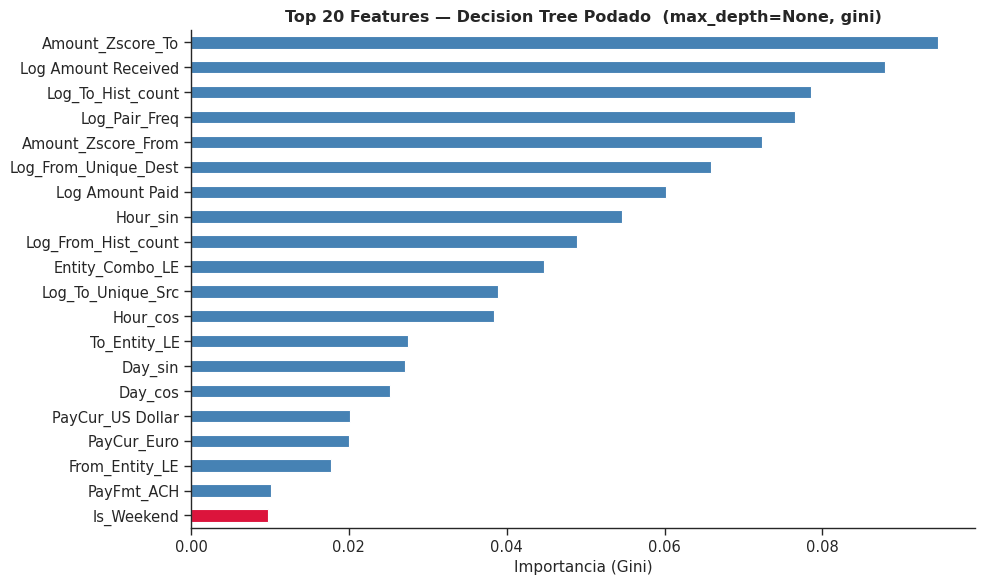

In [22]:
# ── 9.3 Importancia de features del árbol podado ──────────────────────────────
feat_imp = pipe_pruned.named_steps['clf'].feature_importances_
feat_names = X_train.columns.tolist()
feat_imp_series = pd.Series(feat_imp, index=feat_names).sort_values(ascending=False)

top_n = min(20, len(feat_imp_series))
fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['crimson' if i == 0 else 'steelblue' for i in range(top_n)]
feat_imp_series.head(top_n).plot(kind='barh', ax=ax, color=colors_imp[::-1])
ax.invert_yaxis()
ax.set_xlabel('Importancia (Gini)', fontsize=11)
ax.set_title(
    f'Top {top_n} Features — Decision Tree Podado  '
    f'(max_depth={best_d_r9}, {best_crit_r9})',
    fontweight='bold'
)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}feature_importance_dt.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 10 · Tabla Comparativa y Análisis de Convergencia
### 10.1 Tabla de Resultados


Método de Búsqueda  Mejor F1-Score (CV)  Tiempo Total (min)  Iteraciones/Evaluaciones ¿Convergió? Mejor Balanceo
       Grid Search               0.0555               30.85                       270         N/A   Sin balanceo
     Random Search               0.0590                7.21                        60         N/A   Sin balanceo
         Bayesiano               0.0365               12.77                        30          No         ADASYN
   DEAP (Genético)               0.0349               10.31                        50          Sí         ADASYN


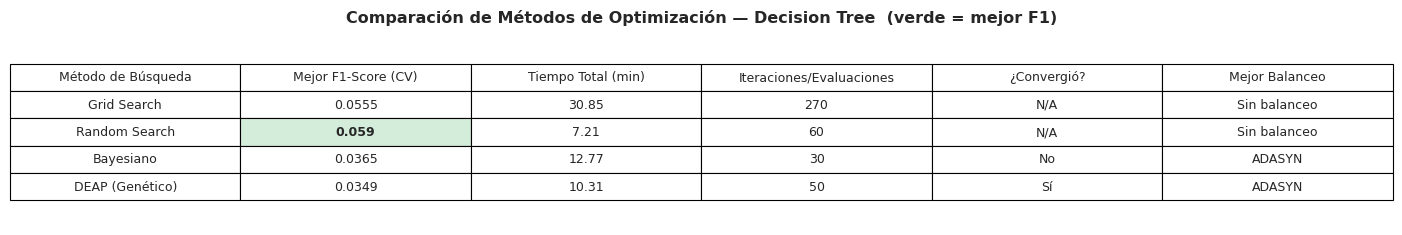

In [23]:
ORDER = ['dt_grid', 'dt_random', 'dt_optuna', 'dt_deap']

rows = []
for k in ORDER:
    r = RESULTS[k]
    rows.append({
        'Método de Búsqueda'       : r['method'],
        'Mejor F1-Score (CV)'      : r['best_f1'],
        'Tiempo Total (min)'       : r['time_min'],
        'Iteraciones/Evaluaciones' : r['n_evals'],
        '¿Convergió?'              : r['converged'],
        'Mejor Balanceo'           : r['best_balance'],
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

display_cols = ['Método de Búsqueda', 'Mejor F1-Score (CV)',
                'Tiempo Total (min)', 'Iteraciones/Evaluaciones',
                '¿Convergió?', 'Mejor Balanceo']

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.axis('off')
tbl = ax.table(
    cellText  = comparison_df[display_cols].values,
    colLabels = display_cols,
    cellLoc   = 'center',
    loc       = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.7)

best_row = comparison_df['Mejor F1-Score (CV)'].idxmax()
f1_col   = display_cols.index('Mejor F1-Score (CV)')
tbl[best_row + 1, f1_col].set_facecolor('#d4edda')
tbl[best_row + 1, f1_col].set_text_props(fontweight='bold')

plt.title('Comparación de Métodos de Optimización — Decision Tree  (verde = mejor F1)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}tabla_comparacion_dt.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.2 Convergencia Bayesiana (Optuna)


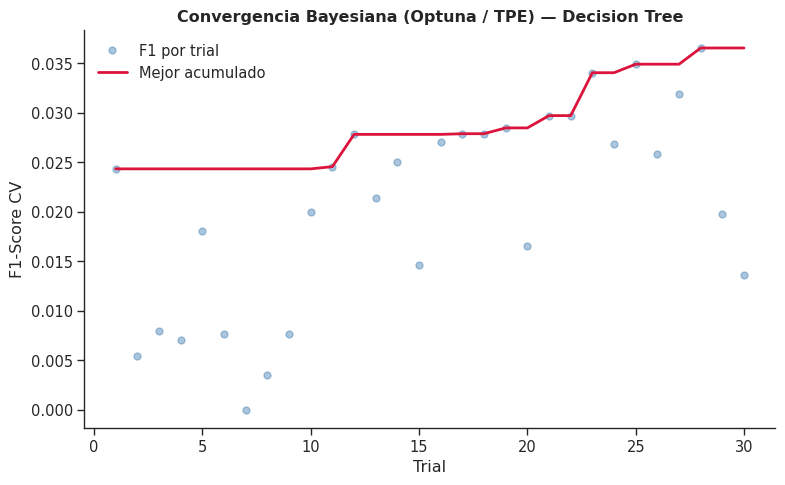

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

study    = RESULTS['dt_optuna']['study']
trial_f1 = [t.value for t in study.trials if t.value is not None]
best_so_far = [max(trial_f1[:i + 1]) for i in range(len(trial_f1))]

ax.plot(range(1, len(trial_f1) + 1), trial_f1,
        'o', color='steelblue', alpha=0.45, ms=5, label='F1 por trial')
ax.plot(range(1, len(best_so_far) + 1), best_so_far,
        '-', color='crimson', lw=2, label='Mejor acumulado')
ax.set_xlabel('Trial')
ax.set_ylabel('F1-Score CV')
ax.set_title('Convergencia Bayesiana (Optuna / TPE) — Decision Tree', fontweight='bold')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}convergencia_optuna_dt.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.3 Convergencia Genética (DEAP)


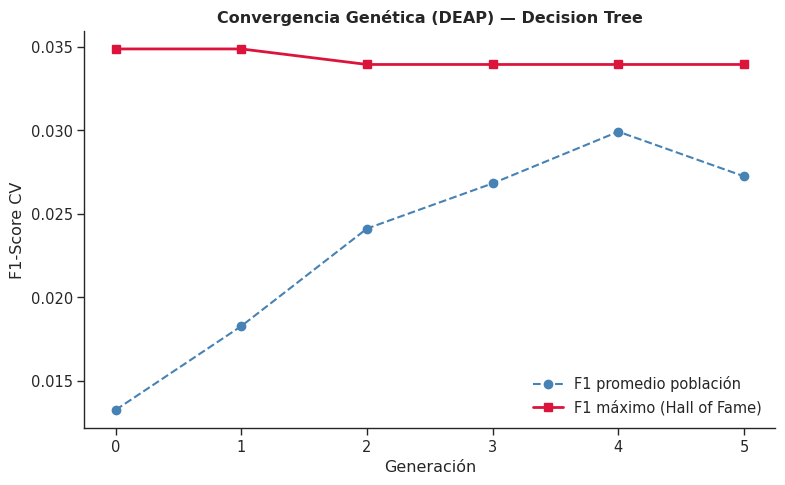

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

lb   = RESULTS['dt_deap']['logbook']
gens = lb.select('gen')
avgs = lb.select('avg')
maxs = lb.select('max')

ax.plot(gens, avgs, 'o--', color='steelblue', lw=1.5, ms=6, label='F1 promedio población')
ax.plot(gens, maxs, 's-',  color='crimson',   lw=2,   ms=6, label='F1 máximo (Hall of Fame)')
ax.set_xlabel('Generación')
ax.set_ylabel('F1-Score CV')
ax.set_title('Convergencia Genética (DEAP) — Decision Tree', fontweight='bold')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}convergencia_deap_dt.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.4 Eficiencia: F1 vs Tiempo


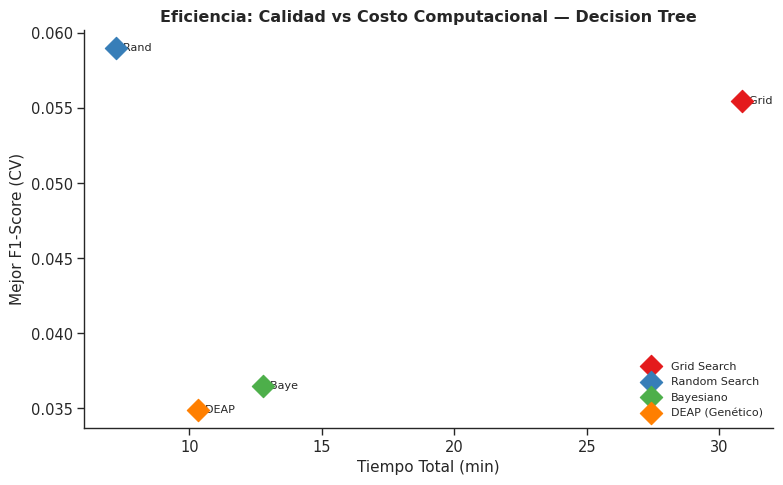

In [26]:
colors_method = {
    'Grid Search'    : '#E41A1C',
    'Random Search'  : '#377EB8',
    'Bayesiano'      : '#4DAF4A',
    'DEAP (Genético)': '#FF7F00',
}

fig, ax = plt.subplots(figsize=(8, 5))

for k in ORDER:
    r = RESULTS[k]
    ax.scatter(r['time_min'], r['best_f1'],
               color  = colors_method[r['method']],
               marker = 'D',
               s      = 130,
               zorder = 5,
               label  = r['method'])
    ax.annotate(
        f"  {r['method'][:4]}",
        (r['time_min'], r['best_f1']),
        fontsize=8, va='center',
    )

ax.set_xlabel('Tiempo Total (min)', fontsize=11)
ax.set_ylabel('Mejor F1-Score (CV)', fontsize=11)
ax.set_title('Eficiencia: Calidad vs Costo Computacional — Decision Tree',
             fontweight='bold')
ax.legend(frameon=False, fontsize=8)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}eficiencia_dt.png', dpi=150, bbox_inches='tight')
plt.show()

Se observa claramente que Random Search (Rand) es la estrategia más eficiente en este escenario, ya que logra el F1-Score más alto (cercano a 0.059) en el menor tiempo posible (menos de 10 minutos). Por el contrario, Grid Search resulta ser el método más costoso, requiriendo más de 30 minutos para alcanzar un F1-Score ligeramente inferior (alrededor de 0.055), mientras que los enfoques Bayesiano (Baye) y genético (DEAP) muestran un rendimiento considerablemente bajo (por debajo de 0.040) a pesar de tomar tiempos intermedios de ejecución.

## Sección 11 · Evaluación Final y Exportación del Mejor Modelo


In [27]:
# ── 11.1 Identificar la mejor configuración global ────────────────────────────
best_key = max(RESULTS, key=lambda k: RESULTS[k]['best_f1'])
best_res = RESULTS[best_key]

print(f"{'═'*62}")
print(f" MEJOR CONFIGURACIÓN GLOBAL")
print(f"{'═'*62}")
print(f" Método     : {best_res['method']}")
print(f" F1-Score   : {best_res['best_f1']}")
print(f" Balanceo   : {best_res['best_balance']}")
print(f" Parámetros :")
for k, v in best_res['spec'].items():
    print(f"   {k:<22}: {v}")
print(f"{'═'*62}\n")

══════════════════════════════════════════════════════════════
 MEJOR CONFIGURACIÓN GLOBAL
══════════════════════════════════════════════════════════════
 Método     : Random Search
 F1-Score   : 0.059
 Balanceo   : Sin balanceo
 Parámetros :
   bal_id                : 0
   max_depth             : 19
   min_samples_split     : 22
   min_samples_leaf      : 7
   criterion             : gini
══════════════════════════════════════════════════════════════



In [28]:
# ── 11.2 Refit en todo X_train ────────────────────────────────────────────────
print("Entrenando modelo final en todo X_train...")
final_model = build_final_model(best_res['spec'], X_train, y_train)
print("Modelo final entrenado ✓\n")

dt_final = final_model.named_steps['clf']
print(f"  Criterio       : {dt_final.criterion}")
print(f"  max_depth      : {dt_final.max_depth}")
print(f"  min_samp_split : {dt_final.min_samples_split}")
print(f"  min_samp_leaf  : {dt_final.min_samples_leaf}")

Entrenando modelo final en todo X_train...
Modelo final entrenado ✓

  Criterio       : gini
  max_depth      : 19
  min_samp_split : 22
  min_samp_leaf  : 7


══════════════════════════════════════════════════════════════
 EVALUACIÓN FINAL EN TEST — Decision Tree — Random Search
══════════════════════════════════════════════════════════════
 Accuracy         : 0.9984
 Precision Lavado : 0.7107
 Recall    Lavado : 0.1407
 F1-Score  Lavado : 0.2349
 ROC-AUC          : 0.6900
 PR-AUC           : 0.2277

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00   1013870
      Lavado       0.71      0.14      0.23      1798

    accuracy                           1.00   1015668
   macro avg       0.85      0.57      0.62   1015668
weighted avg       1.00      1.00      1.00   1015668



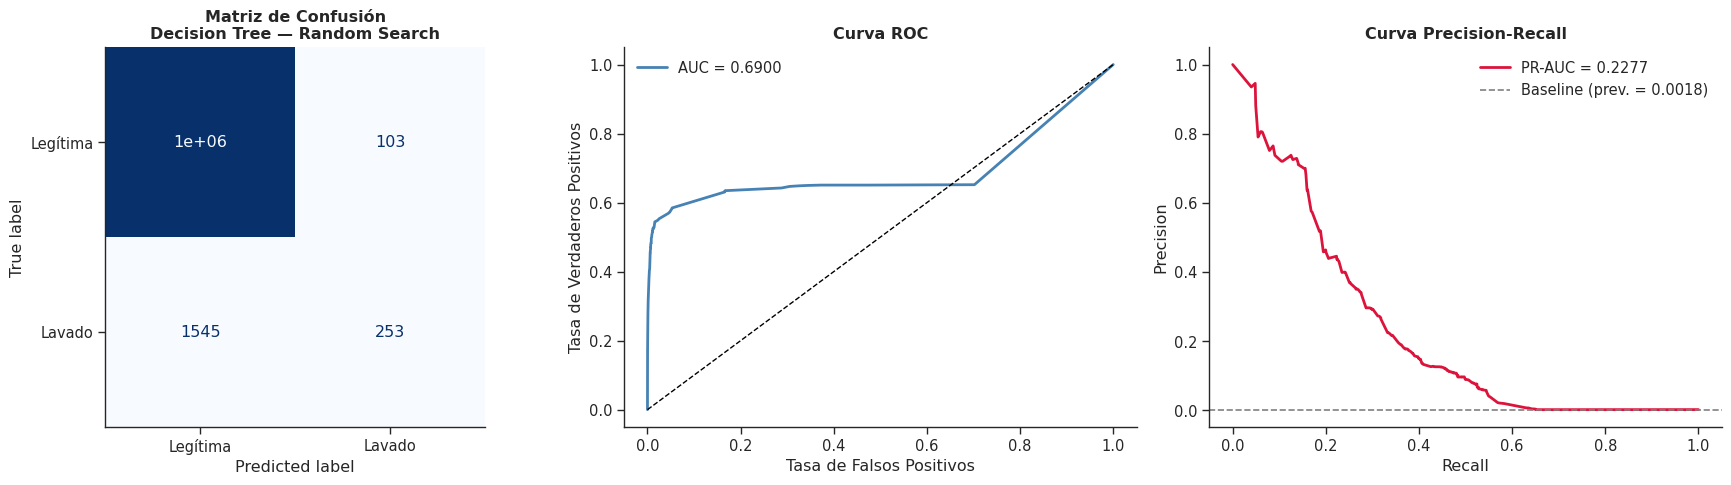

In [29]:
# ── 11.3 Predicciones sobre test ──────────────────────────────────────────────
y_pred_final, y_proba_final = predict_final(final_model, X_test)

# ── 11.4 Evaluación completa ──────────────────────────────────────────────────
def evaluate_final_model(y_true, y_pred, y_proba, title):
    """Imprime métricas y genera: matriz de confusión, curva ROC, curva PR."""
    report  = classification_report(y_true, y_pred,
                                    target_names=['Legítima', 'Lavado'],
                                    output_dict=True)
    prec_c, rec_c, _ = precision_recall_curve(y_true, y_proba)
    fpr, tpr, _      = roc_curve(y_true, y_proba)
    pr_auc  = auc(rec_c, prec_c)
    roc_auc = auc(fpr, tpr)

    print(f"{'═'*62}")
    print(f" EVALUACIÓN FINAL EN TEST — {title}")
    print(f"{'═'*62}")
    print(f" Accuracy         : {report['accuracy']:.4f}")
    print(f" Precision Lavado : {report['Lavado']['precision']:.4f}")
    print(f" Recall    Lavado : {report['Lavado']['recall']:.4f}")
    print(f" F1-Score  Lavado : {report['Lavado']['f1-score']:.4f}")
    print(f" ROC-AUC          : {roc_auc:.4f}")
    print(f" PR-AUC           : {pr_auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Legítima','Lavado'])}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Matriz de confusión
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=['Legítima', 'Lavado']
                           ).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Matriz de Confusión\n{title}', fontweight='bold')

    # Curva ROC
    axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].legend(frameon=False)

    # Curva Precision-Recall
    axes[2].plot(rec_c, prec_c, lw=2, color='crimson', label=f'PR-AUC = {pr_auc:.4f}')
    axes[2].axhline(y_true.mean(), color='gray', linestyle='--', lw=1.2,
                    label=f'Baseline (prev. = {y_true.mean():.4f})')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Curva Precision-Recall', fontweight='bold')
    axes[2].legend(frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'{BASE_PATH}evaluacion_final_dt.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'roc_auc': roc_auc, 'pr_auc': pr_auc}


eval_metrics = evaluate_final_model(
    y_test, y_pred_final, y_proba_final,
    title=f"Decision Tree — {best_res['method']}"
)

- El problema:  El Accuracy del 99.84% es un espejismo; si el modelo dijera siempre "legítima" fallando en todo, tendría 99.82%.

- Lo preocupante (Recall = 14%): El modelo deja pasar el 86% de los casos de lavado. No es útil para detectar el fraude en un escenario real.

- o positivo (Precision = 71%): Cuando el modelo genera una alerta de lavado, acierta 7 de cada 10 veces, lo que genera pocos falsos positivos.

- El diagnóstico (F1-Score = 0.23 / PR-AUC = 0.22): El rendimiento real es muy pobre porque el pésimo Recall arrastra por completo al modelo.

In [30]:
# ── 11.5 Exportaciones ────────────────────────────────────────────────────────
# Probabilidades para Comparacion_Benchmarks.ipynb (Test de DeLong + Bootstrap)
pd.DataFrame({'y_proba_dt': y_proba_final}).to_parquet(
    f'{BASE_PATH}y_proba_dt.parquet', index=False
)

# Modelo serializado
joblib.dump(final_model, f'{BASE_PATH}model_dt.joblib')

print(f"\n{'═'*62}")
print(f" Archivos exportados a Drive:")
print(f"   ✓ y_proba_dt.parquet           (para Comparacion_Benchmarks.ipynb)")
print(f"   ✓ model_dt.joblib              (modelo final serializado)")
print(f"   ✓ tabla_comparacion_dt.png")
print(f"   ✓ convergencia_optuna_dt.png")
print(f"   ✓ convergencia_deap_dt.png")
print(f"   ✓ eficiencia_dt.png")
print(f"   ✓ evaluacion_final_dt.png")
print(f"   ✓ depth_curve_dt.png")
print(f"   ✓ feature_importance_dt.png")
print(f"{'═'*62}")


══════════════════════════════════════════════════════════════
 Archivos exportados a Drive:
   ✓ y_proba_dt.parquet           (para Comparacion_Benchmarks.ipynb)
   ✓ model_dt.joblib              (modelo final serializado)
   ✓ tabla_comparacion_dt.png
   ✓ convergencia_optuna_dt.png
   ✓ convergencia_deap_dt.png
   ✓ eficiencia_dt.png
   ✓ evaluacion_final_dt.png
   ✓ depth_curve_dt.png
   ✓ feature_importance_dt.png
══════════════════════════════════════════════════════════════
